## General

In [1]:
from collections import defaultdict
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Load data
with open('../record/finalstep_stats_3.json') as f:
    data = json.load(f)
with open('../record/finalrandla_stats_3.json') as f2:
    data2 = json.load(f2)
with open('../record/finalmean_stats_3.json') as f3:
    data3 = json.load(f3)
with open('../record/finalcombine_stats_3.json') as f4:
    data4 = json.load(f4)

def euclidean(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


# Environment mapping: (start_point, goal_point) with  environment name
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Function to map (start_point, goal_point) to environment name
def get_env_name(start_point, goal_point, max_snap_dist=5.0):
    # Exact rounded lookup (backwards compatible)
    start_rounded = tuple(round(x) for x in start_point)
    goal_rounded = tuple(round(x) for x in goal_point)
    key = (start_rounded, goal_rounded)

    if key in env_map:
        return env_map[key]

    # Find closest template pair in env_map
    best_name = None
    best_dist = float("inf")

    for (tmpl_start, tmpl_goal), name in env_map.items():
        dist = euclidean(start_point, tmpl_start) + euclidean(goal_point, tmpl_goal)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    # Snap if close enough
    if best_dist <= max_snap_dist:
        return best_name

    # Fallback: keep explicit mapping
    return f"{start_rounded}→{goal_rounded}"


# Process data to compute stats per environment
def process_data(data):
    groups = defaultdict(list)

    for entry in data:
        env_key = get_env_name(entry["start_point"], entry["goal_point"])
        groups[env_key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # Distances involving current_pos
        dist_start_curr = [
            euclidean(entry["start_point"], entry["current_pos"]) for entry in group
        ]
        dist_curr_goal = [
            euclidean(entry["current_pos"], entry["goal_point"]) for entry in group
        ]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)
        N = len(collision_counts)
        if N > 1:
            std_dev = np.std(collision_counts, ddof=1) # Standard Deviation
            sem_collision = std_dev / math.sqrt(N)     # Standard Error
        else:
            sem_collision = 0.0


        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        success_collision_counts = [
            entry["collision_count"] for entry in group if entry.get("reach_goal")
        ]
        mean_collision_success = (
            sum(success_collision_counts) / len(success_collision_counts)
            if success_collision_counts else 0.0
        )

        # ---------------------------------------------
        # Flip-over metric:
        #   reach_goal == False AND count != 700
        # ---------------------------------------------
        flip_over_flags = [
            (not entry["reach_goal"]) and (entry["count"] != 700)
            for entry in group
        ]
        flip_over_count = sum(flip_over_flags)          
        flip_over_rate = flip_over_count / len(group) * 100.0  

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "std_collision": sem_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal,
            "mean_collision_success": mean_collision_success,
            "flip_over_count": flip_over_count,        
            "flip_over_rate": flip_over_rate,          
        }
    return stats

# Process all datasets
stats1 = process_data(data)
stats2 = process_data(data2)
stats3 = process_data(data3)
stats4 = process_data(data4)



In [3]:
# Standardize environment labels using canonical_map and ensure consistent ordering for plotting
plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 12,     
    'axes.labelsize': 12,     
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12,   
    'legend.fontsize': 12, 
    # 'font.family': 'serif',   # Matches typical thesis font (Times New Roman-ish)
})

desired_order = ['Normal', 'Uneven', 'Cliff',  'Multi Ramp', 'Ramp with Obs','Hole']
canonical_map = {

    ((-30, 7), (-22, 17)): "Normal",
    ((-30, -20), (-22, -6)): "Uneven",
    ((-31, -44), (-20, -37)): "Multi Ramp",
    ((-55, 5), (-41, 5)): "Cliff",
    ((-33, 40), (-20, 40)): "Ramp with Obs",
    ((-55, -13), (-41, -13)): "Hole",
    
    # mapping from env_key to canonical label
    "normal": "Normal",
    "uneven": "Uneven",
    "two_height_ramp": "Cliff",         
    "ramp_obstacle": "Ramp with Obs",   
    "mutlti ramp": "Multi Ramp",        
    "multi ramp": "Multi Ramp",
    "hole": "Hole"
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # Check if key is in our map 
        if key in canonical_map:
            label = canonical_map[key]
        elif str(key) in canonical_map:
            label = canonical_map[str(key)]
        else:
            # Fallback for unexpected keys
            label = str(key)
            
        new_stats[label] = values
    return new_stats

## Print stats

In [4]:

# Environment mapping (same as before)
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def get_env_name(start_point, goal_point):
    """Round points and look up in env_map, fallback to 'start→goal' string."""
    start = tuple(round(x) for x in start_point)
    goal = tuple(round(x) for x in goal_point)
    return env_map.get((start, goal), f"{start}→{goal}")

# count how many successful runs per map for RandLA (data2)
map_counts = defaultdict(int)

for entry in data2:
    # if entry.get('reach_goal'):  # only successful runs; remove this if you want all runs
    map_name = get_env_name(entry["start_point"], entry["goal_point"])
    map_counts[map_name] += 1

# print map counts
print(dict(map_counts))

{'normal': 20, 'uneven': 20, 'mutlti ramp': 20, 'two_height_ramp': 20, 'ramp_obstacle': 20, 'hole': 20}


In [5]:
def get_overall_stats(raw_data_list):
    if not raw_data_list:
        return {}

    total_items = 120
    
    # Extract lists for raw data
    total_lengths = [sum(x["total_length"]) for x in raw_data_list]
    collision_counts = [x["collision_count"] for x in raw_data_list]
    steps = [x["count"] for x in raw_data_list]
    reach_goals = [x["reach_goal"] for x in raw_data_list]

    # Calculate Means
    mean_length = sum(total_lengths) / total_items
    mean_collision = sum(collision_counts) / total_items
    mean_steps = sum(steps) / total_items
    success_rate = (sum(reach_goals) / total_items) * 100

    # Calculate Variances / Standard Deviations
    def get_std(data_list, mean):
        if not data_list: return 0.0
        variance = sum((x - mean) ** 2 for x in data_list) / total_items
        return math.sqrt(variance)

    std_length = get_std(total_lengths, mean_length)
    std_collision = get_std(collision_counts, mean_collision)
    std_steps = get_std(steps, mean_steps)

    return {
        "success_rate": success_rate,
        "mean_collision": mean_collision,
        "std_collision": std_collision,
        "mean_length": mean_length,
        "std_length": std_length,
        "mean_steps": mean_steps,
        "std_steps": std_steps,
    }

all_datasets = {
    "STEP": data,
    "RandLA-Net": data2,
    "STEP + RandLA-Net": data3,
    "HyPER": data4,
}

print(f"{'Method':<18} | {'Success%':<9} | {'Collisions (±σ)':<18} | {'Distance (±σ)':<18}|{'Steps (±σ)':<18}")
print("-" * 80)

for method_name, raw_data in all_datasets.items():
    overall = get_overall_stats(raw_data)
    
    # Format strings to include the Mean ± StdDev
    coll_str = f"{overall['mean_collision']:.2f} (±{overall['std_collision']:.2f})"
    dist_str = f"{overall['mean_length']:.2f} (±{overall['std_length']:.2f})"
    steps_str = f"{overall['mean_steps']:.2f} (±{overall['std_steps']:.2f})"
    print(
        f"{method_name:<18} | "
        f"{overall['success_rate']:<9.2f} | "
        f"{coll_str:<18} | "
        f"{dist_str:<18} | "
        f"{steps_str:<18}"
    )

Method             | Success%  | Collisions (±σ)    | Distance (±σ)     |Steps (±σ)        
--------------------------------------------------------------------------------
STEP               | 38.33     | 75.02 (±145.00)    | 111.63 (±129.85)   | 391.25 (±296.77)  
RandLA-Net         | 34.17     | 123.46 (±234.94)   | 99.45 (±156.07)    | 361.73 (±297.13)  
STEP + RandLA-Net  | 51.67     | 97.11 (±219.46)    | 35.64 (±45.47)     | 258.20 (±254.75)  
HyPER              | 60.83     | 41.98 (±110.79)    | 71.23 (±90.32)     | 286.88 (±248.82)  


In [6]:
# Get overall stats
def get_detailed_stats(raw_data):
    groups = defaultdict(list)
    for entry in raw_data:
        # Use your existing get_env_name function
        env = get_env_name(entry["start_point"], entry["goal_point"])
        groups[env].append(entry)

    out = {}
    for env, group in groups.items():
        # Arrays for calculation
        collisions_all = np.array([e["collision_count"] for e in group], dtype=float)
        reach_arr = np.array([e["reach_goal"] for e in group], dtype=bool)
        N = len(group)

        # Stats for ALL runs 
        if N > 0:
            mean_col_all = float(collisions_all.mean())
            std_col_all  = float(collisions_all.std(ddof=1)) if N > 1 else 0.0
            success_count = int(np.sum(reach_arr))
            success_rate  = (success_count / N) * 100.0
        else:
            mean_col_all = 0.0
            std_col_all = 0.0
            success_count = 0
            success_rate = 0.0

        # Stats for SUCCESSFUL runs only
        if success_count > 0:
            collisions_succ = collisions_all[reach_arr]
            mean_col_succ = float(collisions_succ.mean())
            std_col_succ  = float(collisions_succ.std(ddof=1)) if success_count > 1 else 0.0
        else:
            mean_col_succ = None
            std_col_succ = None

        out[env] = {
            "success_rate": success_rate,
            "mean_col_all": mean_col_all,
            "std_col_all": std_col_all,
            "success_count": success_count,
            "mean_col_succ": mean_col_succ,
            "std_col_succ": std_col_succ,
        }
    return out

# Load Your Data 
methods_map = {
    "STEP": data,
    "RandLA-Net": data2,
    "STEP + RandLA": data3,
    "HyPER": data4,
}

# Compute Stats
all_env_stats = {}
for name, raw_data in methods_map.items():
    all_env_stats[name] = get_detailed_stats(raw_data)

# Get sorted list of environments
env_list = sorted({env for m_stats in all_env_stats.values() for env in m_stats.keys()})

# Print Table in Requested Order
for env in env_list:
    print("\n" + "="*105)
    print(f"Environment: {env}")
    # Header Columns: Method | Success% | Mean Collision (All) | # Success | Collision (Success Only)
    print(f"{'Method':<18} | {'Succ %':>7} | {'Mean Coll (All)':>22} | {'# Succ':>8} | {'Coll (Succ Only)':>22}")
    print("-" * 105)

    for name in methods_map.keys():
        stats = all_env_stats[name].get(env)
        if not stats:
            continue
            
        # Format Column 3: Mean Collision (All)
        col_all_str = f"{stats['mean_col_all']:.2f} ±{stats['std_col_all']:.2f}"
        
        # Format Column 5: Mean Collision (Success Only)
        if stats['mean_col_succ'] is not None:
            col_succ_str = f"{stats['mean_col_succ']:.2f} ±{stats['std_col_succ']:.2f}"
        else:
            col_succ_str = "N/A" # No successful runs
            
        print(f"{name:<18} | {stats['success_rate']:>7.1f} | {col_all_str:>22} | {stats['success_count']:>8d} | {col_succ_str:>22}")


Environment: (-53, -13)→(-41, -13)
Method             |  Succ % |        Mean Coll (All) |   # Succ |       Coll (Succ Only)
---------------------------------------------------------------------------------------------------------
STEP               |     0.0 |             0.00 ±0.00 |        0 |                    N/A

Environment: (-53, -14)→(-41, -13)
Method             |  Succ % |        Mean Coll (All) |   # Succ |       Coll (Succ Only)
---------------------------------------------------------------------------------------------------------
STEP               |     0.0 |             1.00 ±0.00 |        0 |                    N/A

Environment: (-54, -13)→(-41, -13)
Method             |  Succ % |        Mean Coll (All) |   # Succ |       Coll (Succ Only)
---------------------------------------------------------------------------------------------------------
STEP               |     0.0 |         171.75 ±342.17 |        0 |                    N/A

Environment: hole
Method         

## PLOT

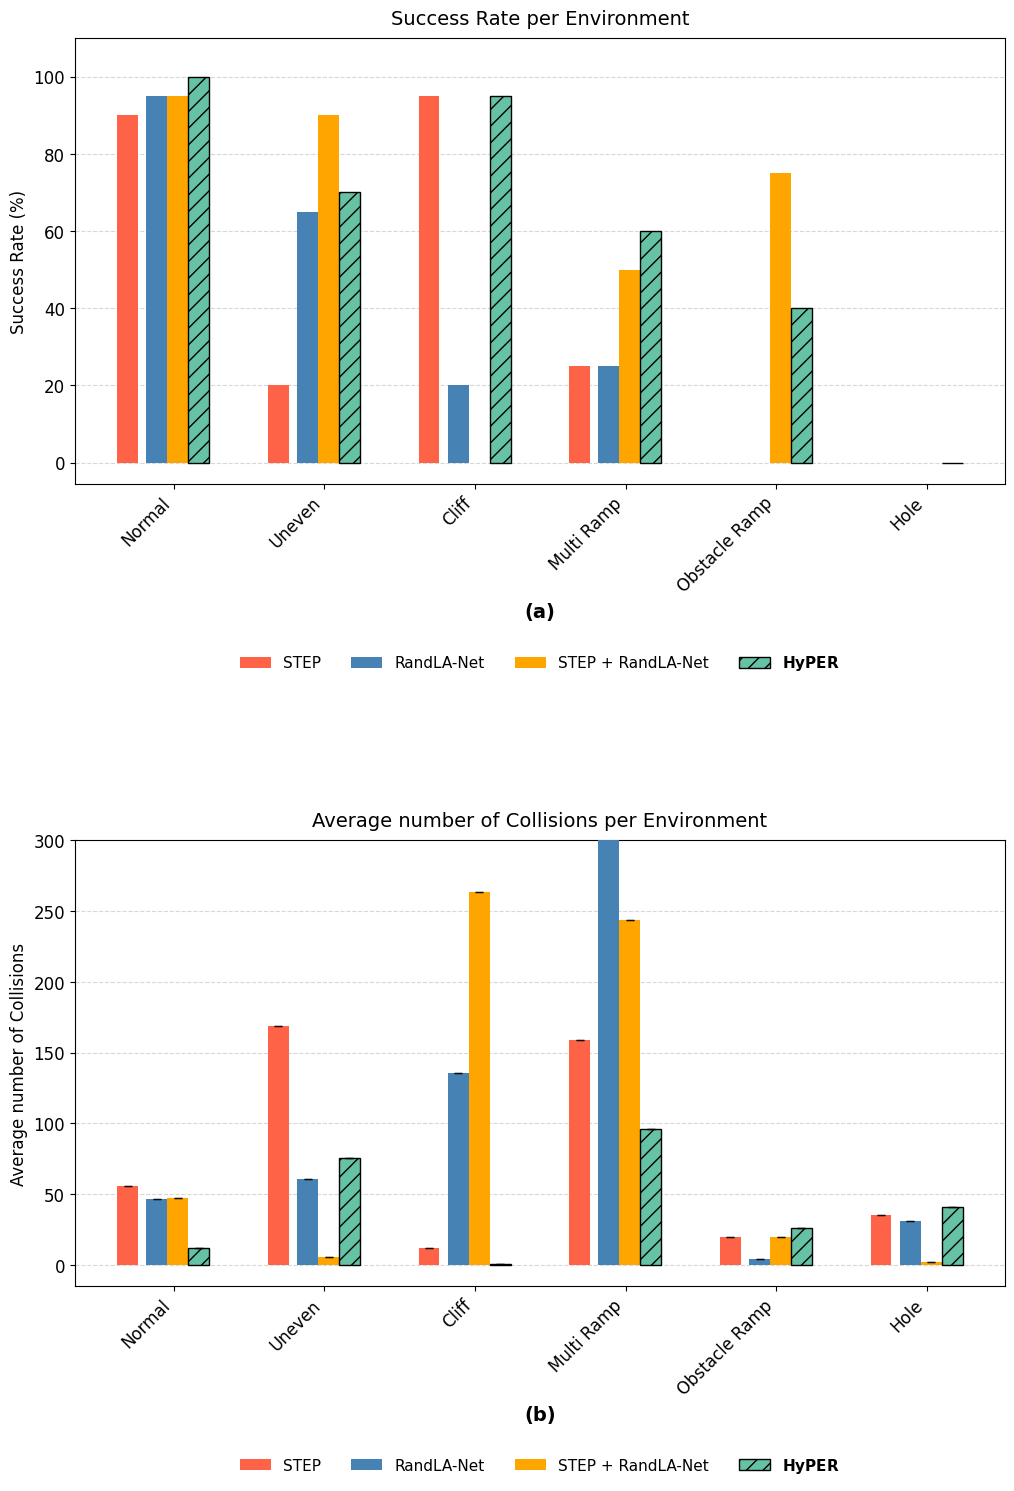

In [7]:
# Apply relabeling
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats6_labeled = relabel_stats(stats4)

# Configuration
env_keys = ['Normal', 'Uneven', 'Cliff', 'Multi Ramp', 'Ramp with Obs', 'Hole']
display_labels = ['Normal', 'Uneven', 'Cliff', 'Multi Ramp', 'Obstacle Ramp', 'Hole']

methods = [
    (stats1_labeled, 'STEP', 'tomato', False),
    (stats2_labeled, 'RandLA-Net', 'steelblue', False),
    (stats3_labeled, 'STEP + RandLA-Net', 'orange', False),
    (stats6_labeled, r'$\bf{HyPER}$', '#66C2A5', True) 
]

# Extract Data
success_data = []
collision_data = []
collision_err = []  # Will hold SEM

for stats, label, _, _ in methods:
    s_rates = [stats.get(env, {}).get("reach_goal_rate", 0) for env in env_keys]
    success_data.append(s_rates)
    
    c_counts = [stats.get(env, {}).get("collision_count", 0) for env in env_keys]
    collision_data.append(c_counts)
    
    # Extract SEM
    c_sem = [stats.get(env, {}).get("sem_collision", 0) for env in env_keys]
    collision_err.append(c_sem)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(12, len(env_keys)*0.8), 16))

# Settings
group_spacing = 1.8
bar_width = 0.25
x = np.arange(len(env_keys)) * group_spacing
offsets = [-2.2*bar_width, -0.8*bar_width, 0.2*bar_width, 1.2*bar_width]

# Subplot 1: Success Rate
for i, (stats, label, color, is_hyper) in enumerate(methods):
    kwargs = {'label': label, 'color': color, 'width': bar_width, 'zorder': 3}
    if is_hyper:
        kwargs.update({'edgecolor': 'black', 'hatch': '//'})
    ax1.bar(x + offsets[i], success_data[i], **kwargs)

ax1.set_ylabel("Success Rate (%)", fontsize=12)
ax1.set_title("Success Rate per Environment", fontsize=14, pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(display_labels, rotation=45, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

ylim_val1 = 110 
ax1.set_ylim(-ylim_val1 * 0.05, ylim_val1)
ax1.text(0.5, -0.30, '(a)', transform=ax1.transAxes, ha='center', fontsize=14, fontweight='bold')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=4, frameon=False, fontsize=11)

# Subplot 2: Collision Count (WITH SEM ERROR BARS)
for i, (stats, label, color, is_hyper) in enumerate(methods):
    kwargs = {
        'label': label, 'color': color, 'width': bar_width, 'zorder': 3,
        'yerr': collision_err[i], 
        'capsize': 3,
        'error_kw': {'elinewidth': 1, 'alpha': 0.7}
    }
    if is_hyper:
        kwargs.update({'edgecolor': 'black', 'hatch': '//'})
    ax2.bar(x + offsets[i], collision_data[i], **kwargs)

ax2.set_ylabel("Average number of Collisions", fontsize=12)
ax2.set_title("Average number of Collisions per Environment", fontsize=14, pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(display_labels, rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

ylim_val2 = 300
ax2.set_ylim(-ylim_val2 * 0.05, ylim_val2)
ax2.text(0.5, -0.30, '(b)', transform=ax2.transAxes, ha='center', fontsize=14, fontweight='bold')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=4, frameon=False, fontsize=11)

plt.subplots_adjust(hspace=0.8, bottom=0.10)
plt.savefig("figures/success_and_collision.png", dpi=300, bbox_inches='tight')
plt.show()

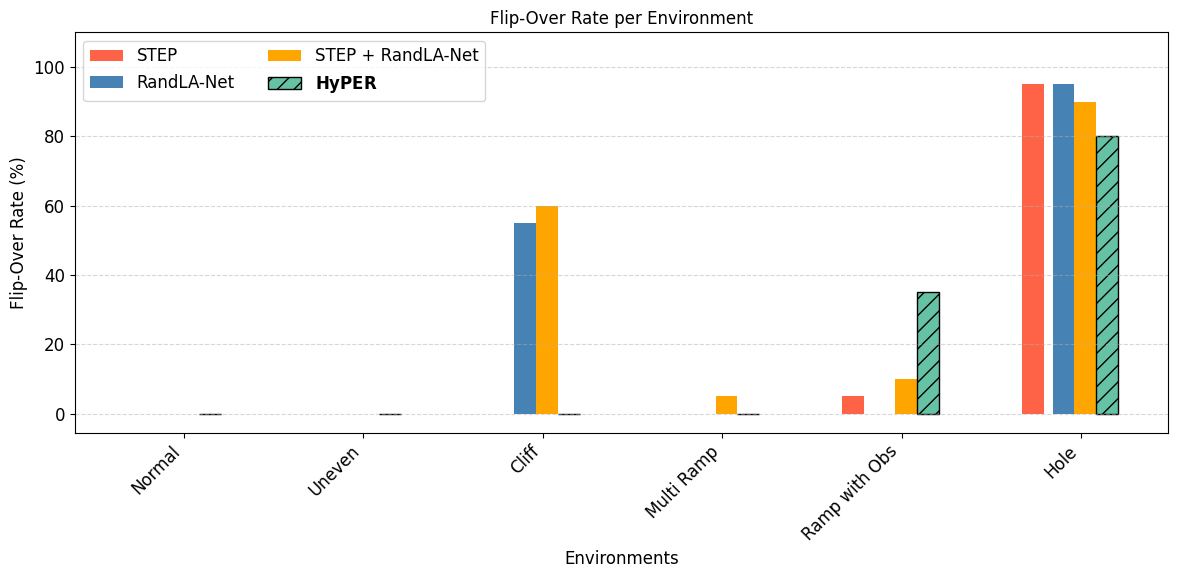

--- Flip-Over Rate (%) ---
  Environment  STEP  RandLA-Net  STEP + RandLA-Net  HyPER
       Normal   0.0         0.0                0.0    0.0
       Uneven   0.0         0.0                0.0    0.0
        Cliff   0.0        55.0               60.0    0.0
   Multi Ramp   0.0         0.0                5.0    0.0
Ramp with Obs   5.0         0.0               10.0   35.0
         Hole  95.0        95.0               90.0   80.0


In [8]:
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)

# Combine all labels with custom order (ensure 'normal' first per settings)
label_set = (
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())

)
all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))
# Build flip-over series
step_flip    = [stats1_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
randla_flip  = [stats2_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
combine_flip = [stats3_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]
full_flip    = [stats4_labeled.get(label, {}).get("flip_over_rate", 0) for label in all_labels]


# Plotting
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # Bar width

offsets = [
    -2.2 * width,  # STEP: Positioned further left
    -0.8 * width,  # RandLA: Start of the right group
     0.2 * width,  # Combine: Middle of the right group
     1.2 * width   # AWARE: End of the right group
]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

plt.bar(x + offsets[0], step_flip,    width, label='STEP', color='tomato')
plt.bar(x + offsets[1], randla_flip,  width, label='RandLA-Net', color='steelblue')
plt.bar(x + offsets[2], combine_flip, width, label='STEP + RandLA-Net', color='orange')

plt.bar(
    x + offsets[3],
    full_flip,
    width,
    label=r'$\bf{HyPER}$',
    color='#66C2A5',
    edgecolor='black',
    hatch='//'
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.xlabel("Environments")
plt.ylabel("Flip-Over Rate (%)")
ylim_val = 110
plt.ylim(-ylim_val*0.05, ylim_val)
plt.title("Flip-Over Rate per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/flip_over_rates.png", dpi=300, bbox_inches='tight')
plt.show()
data = {
    "Environment": all_labels,
    "STEP": step_flip,
    "RandLA-Net": randla_flip,
    "STEP + RandLA-Net": combine_flip,
    "HyPER": full_flip
}

#  Convert to a Pandas DataFrame
df = pd.DataFrame(data)

print("--- Flip-Over Rate (%) ---")
print(df.to_string(index=False))

# df.to_csv("figures/flip_over_rates.csv", index=False)


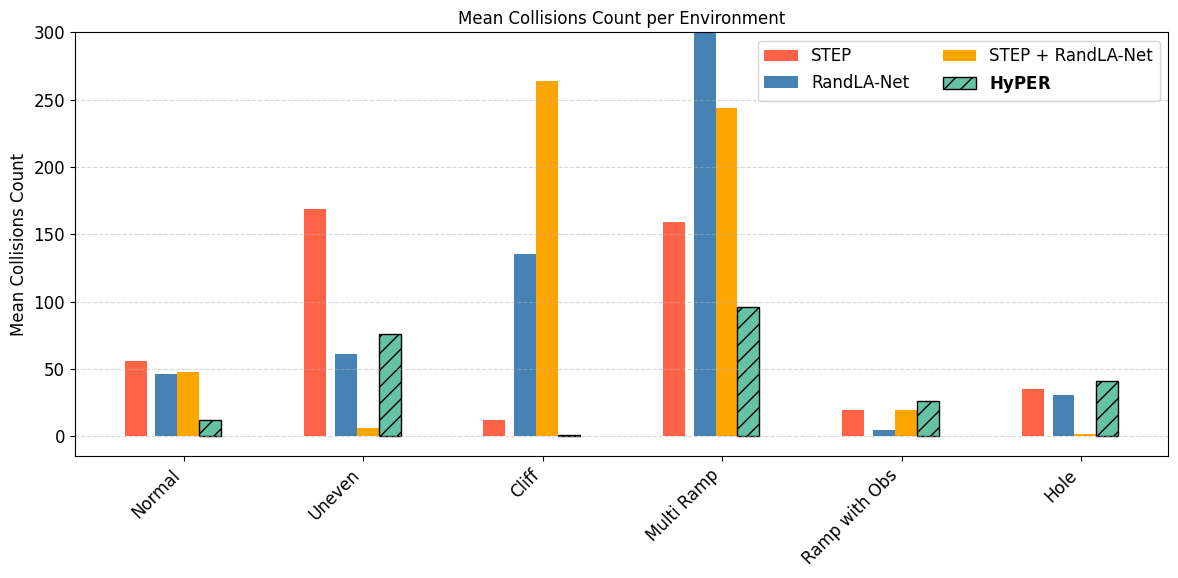

In [9]:
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)  

# Combine all labels with custom order 
label_set = (
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())
)
all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))

# Build arrays (collision_count means)
step_collision_means    = [stats1_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
randla_collision_means  = [stats2_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
combine_collision_means = [stats3_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
full_collision_means    = [stats4_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]

group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # Bar width

offsets = [
    -2.2 * width,  # STEP: Positioned further left
    -0.8 * width,  # RandLA: Start of the right group
     0.2 * width,  # Combine: Middle of the right group
     1.2 * width   # AWARE: End of the right group
]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 6))

bars1 = plt.bar(x + offsets[0], step_collision_means,    width, label='STEP', color='tomato')
bars2 = plt.bar(x + offsets[1], randla_collision_means,  width, label='RandLA-Net', color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_collision_means, width, label='STEP + RandLA-Net', color='orange')

bars6 = plt.bar(
    x + offsets[3],
    full_collision_means,
    width,
    label=r'$\bf{HyPER}$',
    color='#66C2A5',
    edgecolor='black',
    hatch='//'
)

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collisions Count")
plt.title("Mean Collisions Count per Environment")
plt.legend(ncol=2)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Fixed y-limit + annotate only bars exceeding that limit
ylim_val = 300
plt.ylim(-ylim_val*0.05, ylim_val)
plt.tight_layout()
plt.show()


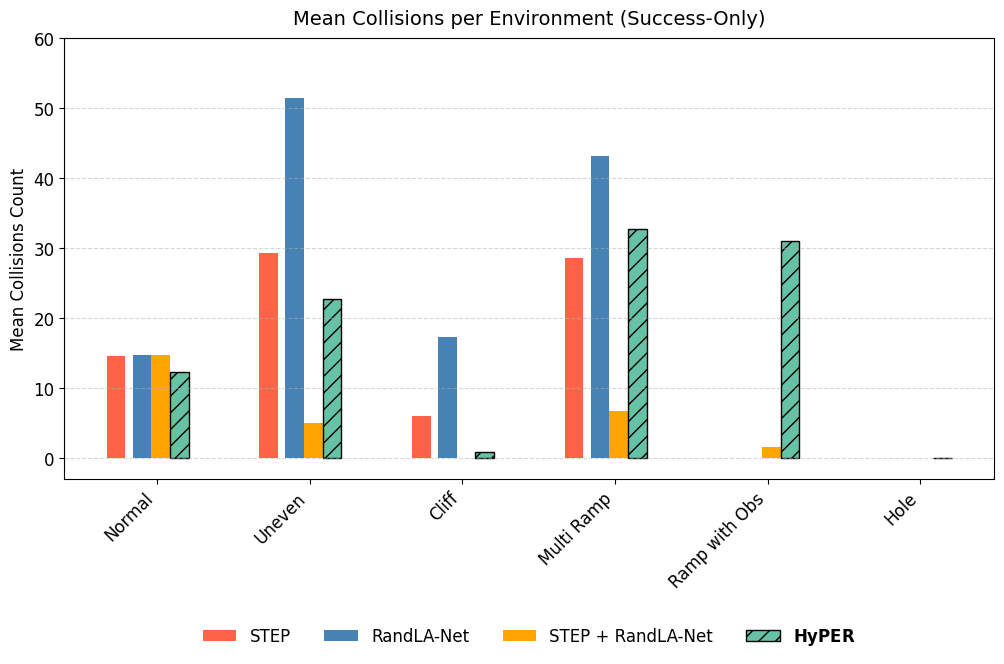

In [10]:
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)

label_set = (
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())
)


all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))

if 'Hole' in all_labels:
    all_labels.remove('Hole')
    all_labels.append('Hole')

# Build arrays from mean_collision_success
step_means    = [stats1_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
randla_means  = [stats2_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
combine_means = [stats3_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
new_means     = [stats4_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]

# Spacing + centered offsets
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.22  # Bar width

offsets = [
    -2.2 * width,  # STEP
    -0.8 * width,  # RandLA
     0.2 * width,  # Combine
     1.2 * width   # HyPER
]

plt.figure(figsize=(max(12, len(all_labels)*0.8), 7)) 

bars1 = plt.bar(x + offsets[0], step_means,    width, label='STEP',              color='tomato')
bars2 = plt.bar(x + offsets[1], randla_means,  width, label='RandLA-Net',        color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_means, width, label='STEP + RandLA-Net', color='orange')
bars6 = plt.bar(x + offsets[3], new_means,     width, label=r'$\bf{HyPER}$',     color='#66C2A5',
                edgecolor='black', hatch='//')

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collisions Count")
plt.title("Mean Collisions per Environment (Success-Only)", fontsize=14, pad=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# Fixed y-limit
ylim_val = 60
plt.ylim(-ylim_val*0.05, ylim_val)

# LEGEND BELOW GRAPH
# bbox_to_anchor=(x, y). y < 0 places it below the axis.
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4, frameon=False, fontsize=12)
plt.subplots_adjust(bottom=0.25)
plt.show()

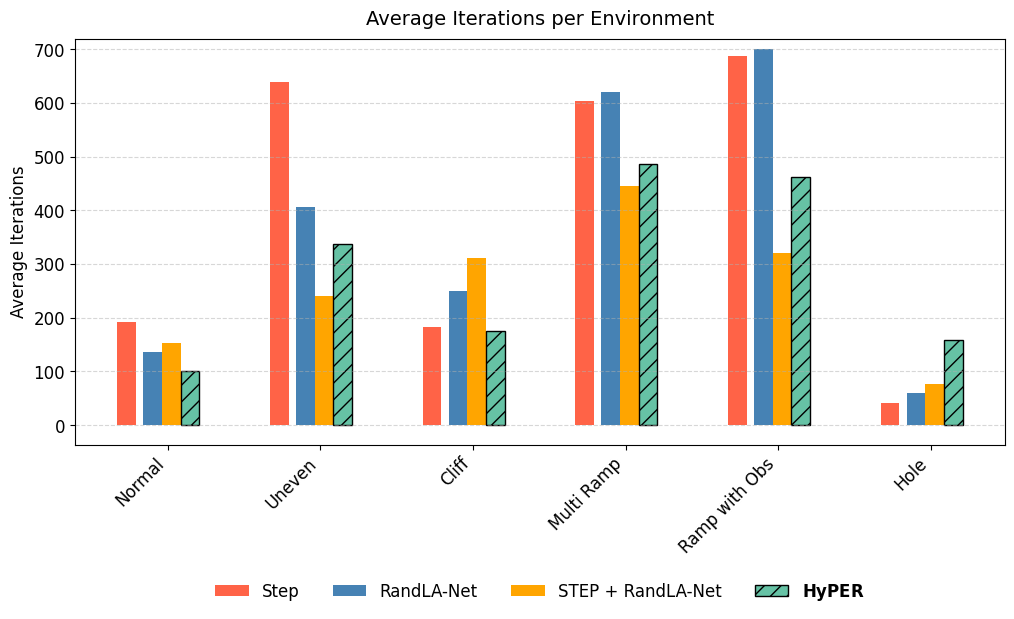

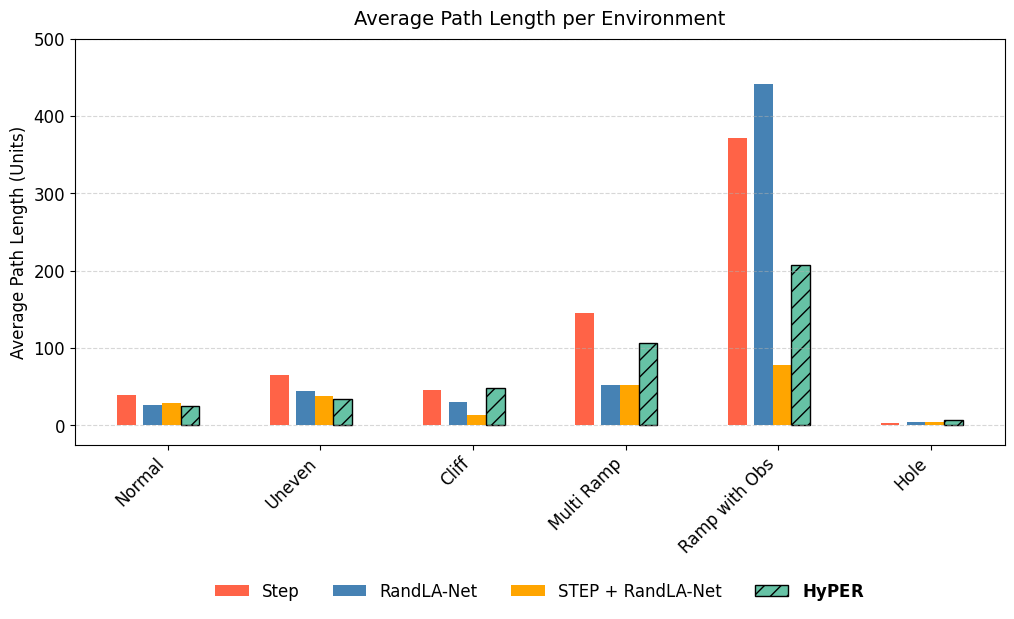

In [11]:
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)

# Combine all labels with custom order
label_set = (
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())

)

# Sort labels based on desired_order
all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))
if 'Hole' in all_labels:
    all_labels.remove('Hole')
    all_labels.append('Hole')

# Extract Data
step_counts     = [stats1_labeled.get(label, {}).get("count", 0) for label in all_labels]
randla_counts   = [stats2_labeled.get(label, {}).get("count", 0) for label in all_labels]
combine_counts  = [stats3_labeled.get(label, {}).get("count", 0) for label in all_labels]
new_counts      = [stats4_labeled.get(label, {}).get("count", 0) for label in all_labels]

step_lengths    = [stats1_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
randla_lengths  = [stats2_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
combine_lengths = [stats3_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
new_lengths     = [stats4_labeled.get(label, {}).get("total_length", 0) for label in all_labels]

# Layout Settings
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing
width = 0.22 

offsets = [
    -2.2 * width,  # STEP
    -0.8 * width,  # RandLA
     0.2 * width,  # Combine
     1.2 * width   # HyPER
]

# ==========================================
# FIGURE 1: MEAN COUNTS (a)
# ==========================================
fig1 = plt.figure(figsize=(max(12, len(all_labels)*0.8), 7))
ax1 = plt.gca()

ax1.bar(x + offsets[0], step_counts,    width, label='Step',              color='tomato')
ax1.bar(x + offsets[1], randla_counts,  width, label='RandLA-Net',        color='steelblue')
ax1.bar(x + offsets[2], combine_counts, width, label='STEP + RandLA-Net', color='orange')
ax1.bar(x + offsets[3], new_counts,     width, label=r'$\bf{HyPER}$',     color='#66C2A5', 
        edgecolor='black', hatch='//')

ax1.set_xticks(x)
ax1.set_xticklabels(all_labels, rotation=45, ha='right')
ax1.set_ylabel("Average Iterations")
ax1.set_title("Average Iterations per Environment", fontsize=14, pad=10)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(-720*0.05, 720) 
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4, frameon=False, fontsize=12)

plt.subplots_adjust(bottom=0.3)
# plt.savefig("TotalCount_NCompare.pdf", format="pdf", bbox_inches='tight')
plt.savefig("figures/average_iterations.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# FIGURE 2: MEAN TOTAL DISTANCE (b)
# ==========================================
fig2 = plt.figure(figsize=(max(12, len(all_labels)*0.8), 7))
ax2 = plt.gca()

ax2.bar(x + offsets[0], step_lengths,    width, label='Step',              color='tomato')
ax2.bar(x + offsets[1], randla_lengths,  width, label='RandLA-Net',        color='steelblue')
ax2.bar(x + offsets[2], combine_lengths, width, label='STEP + RandLA-Net', color='orange')
ax2.bar(x + offsets[3], new_lengths,     width, label=r'$\bf{HyPER}$',     color='#66C2A5',
        edgecolor='black', hatch='//')

ax2.set_xticks(x)
ax2.set_xticklabels(all_labels, rotation=45, ha='right')
ax2.set_ylabel("Average Path Length (Units)")
ax2.set_title("Average Path Length per Environment", fontsize=14, pad=10)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.set_ylim(-500*0.05, 500)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4, frameon=False, fontsize=12)

plt.subplots_adjust(bottom=0.3)
# plt.savefig("TotalDist_NCompare.pdf", format="pdf", bbox_inches='tight')
plt.savefig("figures/average_path_length.png", dpi=300, bbox_inches='tight')
plt.show()